# Ensemble Learning for Bitcoin Return Prediction  
(Bagging, Boosting, and Model Ensemble from Scratch)

In this example, we demonstrate how to:

- Load and preprocess historical Bitcoin price data
- Engineer simple technical features for financial time-series prediction
- Implement Random Forest (bagging) and XGBoost-style gradient boosting from scratch
- Train both models to predict next-day Bitcoin returns
- Combine the two models into a higher-level model ensemble
- Evaluate predictive performance and trading outcomes using a simple backtesting framework
- Interpret the differences between bagging, boosting, and model-level ensemble methods

---

## Example: Bitcoin Daily Price Data

### Overview

The Bitcoin dataset consists of daily historical price observations, including open, high, low, close prices, and trading volume.  
Unlike image datasets such as MNIST, Bitcoin prices form a noisy, non-stationary financial time series in which short-horizon predictability is weak.

The learning task in this notebook focuses on short-term return prediction, a setting where model robustness and variance control are particularly important.

---

### Data Source

The Bitcoin price data is obtained from Yahoo Finance and spans multiple market regimes, including bull markets, bear markets, and sideways periods.

Each observation corresponds to one trading day and includes:

- Open price  
- High price  
- Low price  
- Close price  
- Trading volume  

---

### Feature Engineering

To transform raw prices into a machine-learning-ready representation, the following features are constructed:

Daily return:

$$
r_t = \frac{P_t - P_{t-1}}{P_{t-1}}
$$

Short-term and medium-term moving averages:

$$
\text{SMA}_k(t) = \frac{1}{k} \sum_{i=0}^{k-1} P_{t-i}
$$

Moving-average difference (trend indicator):

$$
\text{SMA\_diff}_t = \text{SMA}_7(t) - \text{SMA}_{30}(t)
$$

Rolling volatility:

$$
\sigma_t = \sqrt{\frac{1}{k-1} \sum_{i=0}^{k-1} (r_{t-i} - \bar{r}_t)^2}
$$

The prediction target is defined as the next-day return:

$$
y_t = r_{t+1}
$$

---

### Learning Task and Output

The learning task is a supervised regression problem:

Given information available up to day \( t \), predict the Bitcoin return on day \( t+1 \).

Formally, we seek a function \( f(\cdot) \) such that

$$
\hat{y}_t = f(X_t)
$$

where \( X_t \) is the feature vector constructed from prices up to time \( t \).

Model outputs are evaluated using:

- Mean squared error  
- Coefficient of determination \( R^2 \)  
- Directional accuracy:

$$
\text{DA} = \frac{1}{T} \sum_{t=1}^{T} \mathbf{1}
\bigl[\text{sign}(\hat{y}_t) = \text{sign}(y_t)\bigr]
$$

---

## Ensemble Methods Used

### Random Forest (Bagging)

The Random Forest model follows the bagging principle.  
Each decision tree is trained on a bootstrap sample of the original dataset:

$$
(X^{(b)}, y^{(b)}) \sim \text{Bootstrap}(X, y)
$$

Each tree learns an independent predictor \( f_m(x) \), and the final prediction is obtained by averaging:

$$
\hat{y}(x) = \frac{1}{M} \sum_{m=1}^{M} f_m(x)
$$

This procedure reduces prediction variance by averaging over many high-variance base learners.

---

### XGBoost-Style Gradient Boosting (Boosting)

The boosting model is implemented as an additive ensemble:

$$
\hat{y}(x) = \sum_{m=0}^{M} \eta f_m(x)
$$

where \( f_0(x) \) is an initial constant predictor and \( \eta \) is the learning rate.

At iteration \( m \), a new tree is trained on the negative gradient of the squared loss:

$$
L(y, \hat{y}) = \frac{1}{2}(y - \hat{y})^2
$$

The gradient with respect to the prediction is

$$
\frac{\partial L}{\partial \hat{y}} = \hat{y} - y
$$

Each tree therefore fits the residual

$$
r^{(m)} = y - \hat{y}^{(m-1)}
$$

Boosting primarily aims to reduce model bias by sequentially correcting previous errors.

---

### Model-Level Ensemble (Resemble)

To combine the complementary properties of bagging and boosting, a model-level ensemble is constructed by averaging predictions from Random Forest and XGBoost:

$$
\hat{y}_{\text{ens}} = \frac{1}{2}\hat{y}_{\text{RF}} + \frac{1}{2}\hat{y}_{\text{XGB}}
$$

This ensemble integrates variance reduction from bagging with bias reduction from boosting.

---

## Stacking Ensemble (Meta-Learning)

In contrast to fixed-weight averaging, stacking introduces a second-level
model that learns how to combine base learner predictions in a data-driven way.

The base models (Random Forest and XGBoost) generate predictions, which are then
used as features for a meta-learner trained on the same prediction task.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("bitcoin_history.csv")

# Date
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df = df.set_index('Date')

for col in ['Open','High','Low','Close','Volume']:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '')
        .astype(float)
    )

df.head()


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-09-17,465.86,468.17,452.42,457.33,457.33,21056800.0
2014-09-18,456.86,456.86,413.10,424.44,424.44,34483200.0
2014-09-19,424.10,427.83,384.53,394.80,394.80,37919700.0
2014-09-20,394.67,423.30,389.88,408.90,408.90,36863600.0
2014-09-21,408.08,412.43,393.18,398.82,398.82,26580100.0


In [4]:
# Daily return
df['ret_1d'] = df['Close'].pct_change()

# Moving averages
df['sma_7'] = df['Close'].rolling(7).mean()
df['sma_30'] = df['Close'].rolling(30).mean()
df['sma_diff'] = df['sma_7'] - df['sma_30']

# Volatility
df['volatility_7d'] = df['ret_1d'].rolling(7).std()

# Target: next-day return
df['target'] = df['ret_1d'].shift(-1)

df = df.dropna()
df.head()


,Open,High,Low,Close,Adj Close,Volume,ret_1d,sma_7,sma_30,sma_diff,volatility_7d,target
Date,,,,,,,,,,,,
2014-10-16,394.52,398.81,373.07,382.56,382.56,26990000.0,-0.030929,381.574286,384.112000,-2.537714,0.027826,0.003137
2014-10-17,382.76,385.48,375.39,383.76,383.76,13600700.0,0.003137,384.745714,381.659667,3.086048,0.026969,0.020013
2014-10-18,383.98,395.16,378.97,391.44,391.44,11416800.0,0.020013,388.908571,380.559667,8.348905,0.027067,-0.004828
2014-10-19,391.25,393.94,386.46,389.55,389.55,5914570.0,-0.004828,390.480000,380.384667,10.095333,0.023058,-0.017199
2014-10-20,389.23,390.08,378.25,382.85,382.85,16419000.0,-0.017199,389.400000,379.516333,9.883667,0.020769,0.009482


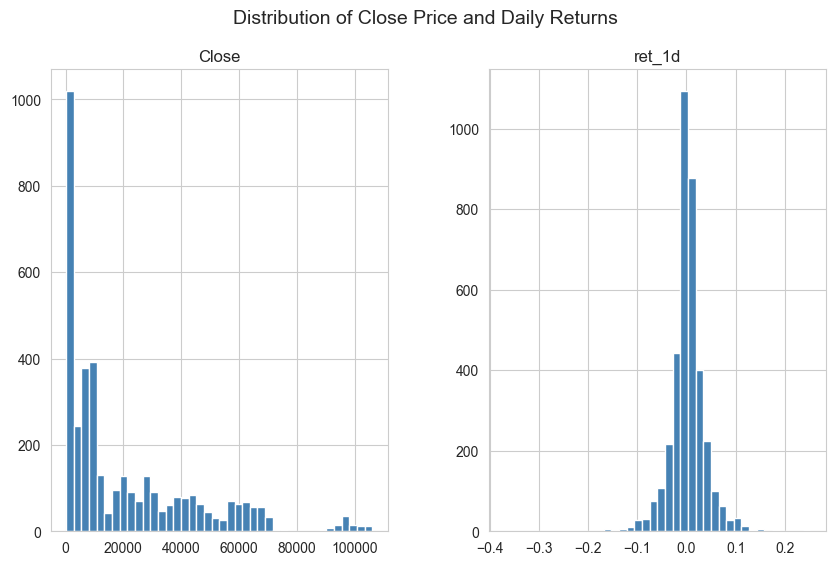

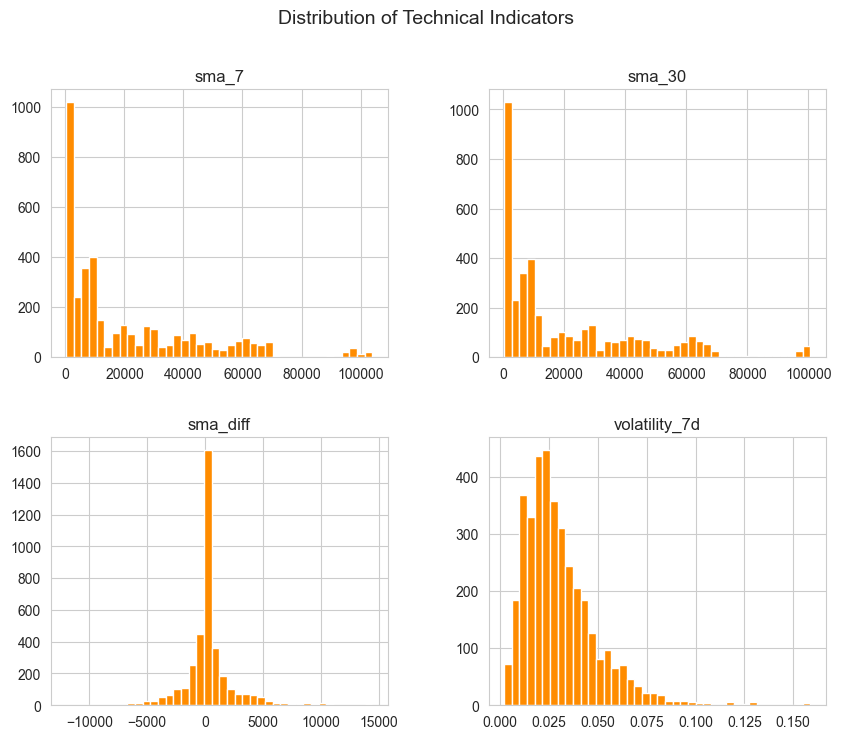

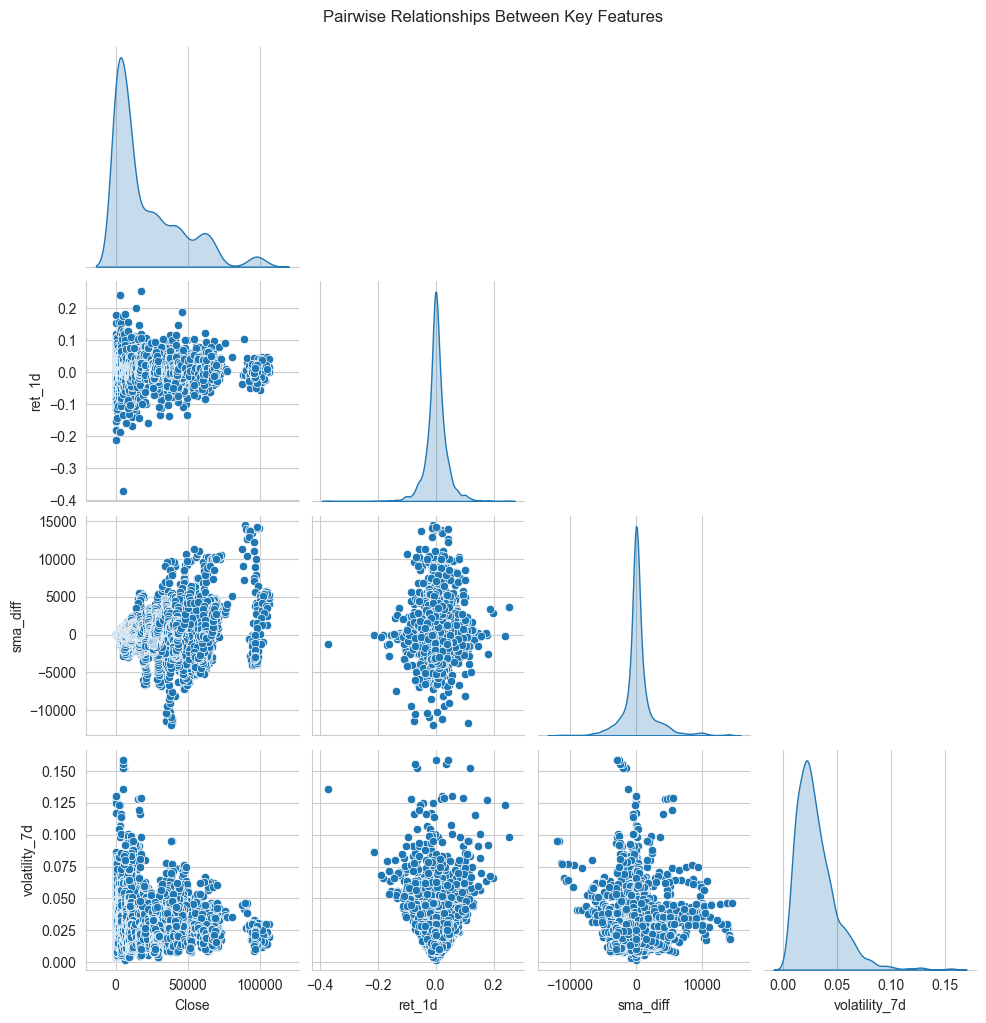

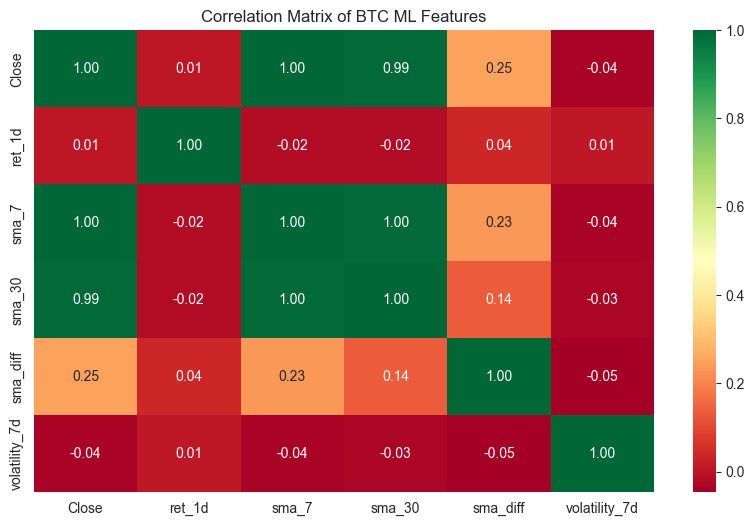

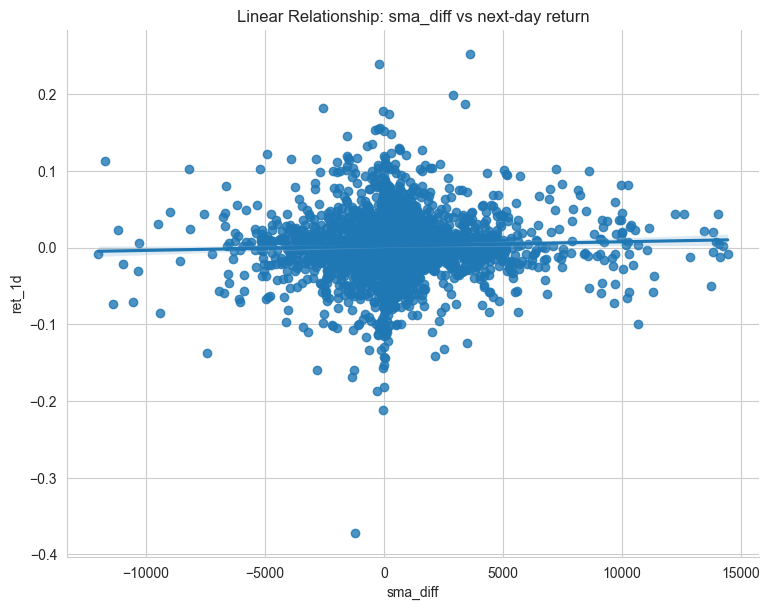

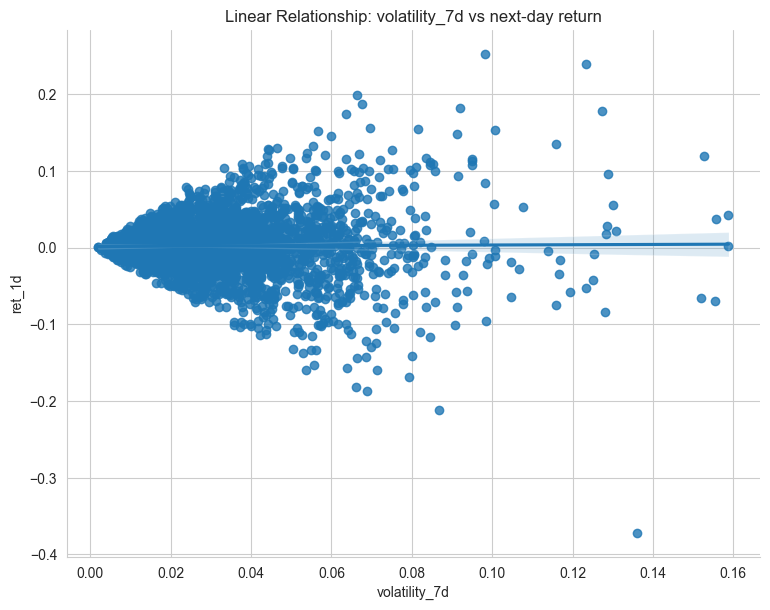

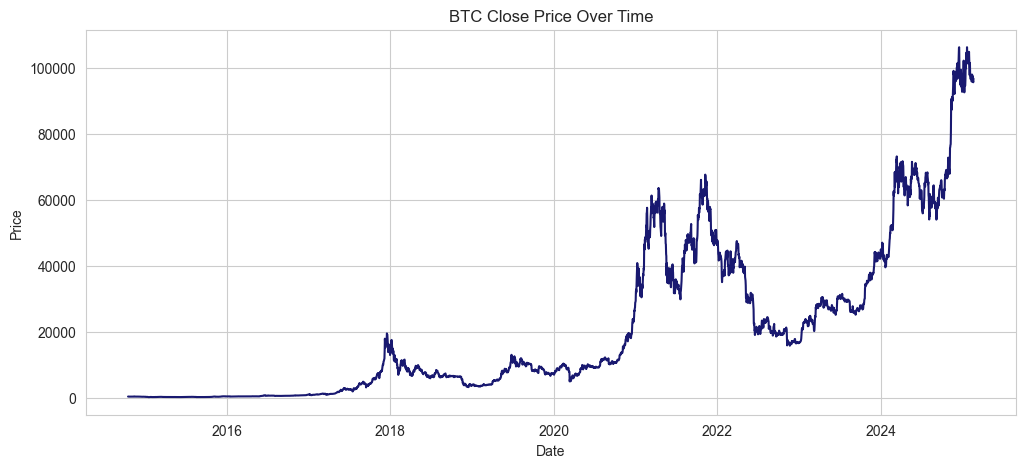

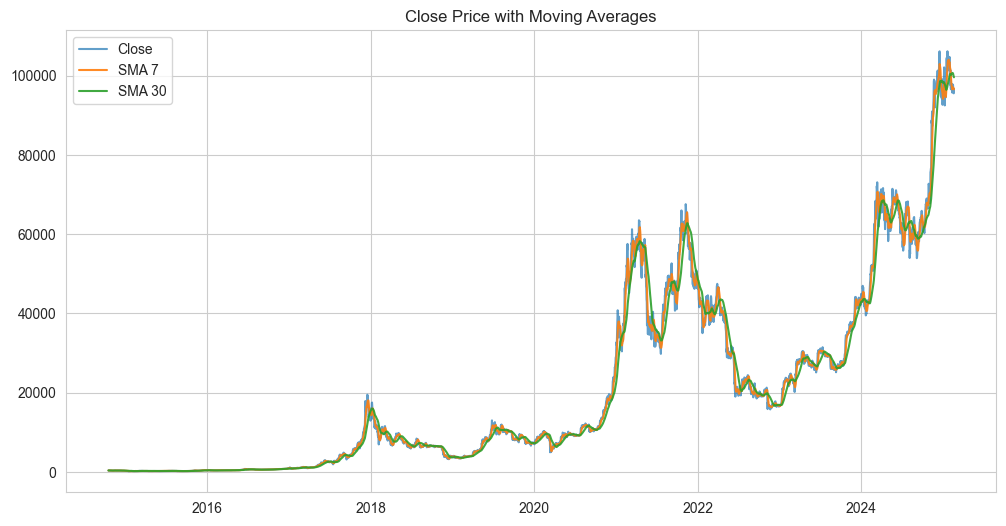

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# ===============================
# 2. histogram
# ===============================
df[['Close', 'ret_1d']].hist(figsize=(10,6), bins=40, color='steelblue')
plt.suptitle("Distribution of Close Price and Daily Returns", fontsize=14)
plt.show()

# ===============================
# 3. indicators distribution
# ===============================
df[['sma_7','sma_30','sma_diff','volatility_7d']].hist(
    figsize=(10,8), bins=40, color='darkorange'
)
plt.suptitle("Distribution of Technical Indicators", fontsize=14)
plt.show()

# ===============================
# 4. Pairplot
# ===============================
sns.pairplot(
    df[['Close','ret_1d','sma_diff','volatility_7d']],
    diag_kind='kde',
    corner=True
)
plt.suptitle("Pairwise Relationships Between Key Features", y=1.02)
plt.show()

# ===============================
# 5. correlation matrix
# ===============================
plt.figure(figsize=(10,6))
corr = df[['Close','ret_1d','sma_7','sma_30','sma_diff','volatility_7d',]].corr()
sns.heatmap(corr, annot=True, cmap='RdYlGn', fmt=".2f")
plt.title("Correlation Matrix of BTC ML Features")
plt.show()

# ===============================
# 6. linear relationship of single variables
# ===============================
sns.lmplot(x='sma_diff', y='ret_1d', data=df, height=6, aspect=1.3)
plt.title("Linear Relationship: sma_diff vs next-day return")
plt.show()

sns.lmplot(x='volatility_7d', y='ret_1d', data=df, height=6, aspect=1.3)
plt.title("Linear Relationship: volatility_7d vs next-day return")
plt.show()

# ===============================
# 7. Close price over time
# ===============================
plt.figure(figsize=(12,5))
plt.plot(df.index, df['Close'], color='midnightblue')
plt.title("BTC Close Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

# ===============================
# 8. visualization
# ===============================
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Close'], label='Close', alpha=0.7)
plt.plot(df.index, df['sma_7'], label='SMA 7', alpha=0.9)
plt.plot(df.index, df['sma_30'], label='SMA 30', alpha=0.9)
plt.title("Close Price with Moving Averages")
plt.legend()
plt.show()

Train / Test Split（Time Series）

In [6]:
feature_cols = ['ret_1d', 'sma_diff', 'volatility_7d']

X = df[feature_cols]
y = df['target']

split = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]


In [7]:
from randomforest import RandomForestRegressorScratch as rf
from xgboost_scratch import XGBoostRegressorScratch as xgb

In [8]:
rf_model = rf(
    n_estimators=200,
    max_depth=5,
    min_samples_leaf=10,
    max_features=0.7,
    random_state=42
)

rf_model.fit(X_train.values, y_train.values)
pred_rf = rf_model.predict(X_test.values)


In [9]:
xgb_model = xgb(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    min_samples_leaf=10,
    random_state=42
)

xgb_model.fit(X_train.values, y_train.values)
pred_xgb = xgb_model.predict(X_test.values)


In [10]:
from sklearn.metrics import mean_squared_error, r2_score

def evaluate_model(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    dir_acc = (np.sign(y_true.values) == np.sign(y_pred)).mean()
    
    print(f"{name}")
    print(f"  MSE: {mse:.6f}")
    print(f"  R2: {r2:.4f}")
    print(f"  Direction Accuracy: {dir_acc:.4f}\n")

evaluate_model("Random Forest (Scratch)", y_test, pred_rf)
evaluate_model("XGBoost (Scratch)", y_test, pred_xgb)


Random Forest (Scratch)
  MSE: 0.000652
  R2: -0.0191
  Direction Accuracy: 0.5053

XGBoost (Scratch)
  MSE: 0.000690
  R2: -0.0778
  Direction Accuracy: 0.5106



In [11]:
# Simple average ensemble
pred_ens = 0.5 * pred_rf + 0.5 * pred_xgb

evaluate_model("Ensemble (RF + XGB)", y_test, pred_ens)


Ensemble (RF + XGB)
  MSE: 0.000663
  R2: -0.0361
  Direction Accuracy: 0.4974



In [12]:
# Base model predictions on TRAIN set
rf_train_pred = rf_model.predict(X_train.values)
xgb_train_pred = xgb_model.predict(X_train.values)

# Stack predictions as new features
X_meta_train = np.column_stack([
    rf_train_pred,
    xgb_train_pred
])

y_meta_train = y_train.values

X_meta_train[:5], y_meta_train[:5]

(array([[0.00118577, 0.00352756],
        [0.00163006, 0.0104158 ],
        [0.00436711, 0.01873162],
        [0.00184813, 0.00267751],
        [0.00157697, 0.00032587]]),
 array([ 0.00313676,  0.02001251, -0.00482833, -0.01719933,  0.00948152]))

In [15]:
from sklearn.linear_model import Ridge

meta_model = Ridge(alpha=1.0)
meta_model.fit(X_meta_train, y_meta_train)


,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [16]:
meta_model.coef_

array([0.12028904, 0.42663595])

In [17]:
# Base model predictions on TEST set
rf_test_pred = rf_model.predict(X_test.values)
xgb_test_pred = xgb_model.predict(X_test.values)

# Meta features for test
X_meta_test = np.column_stack([
    rf_test_pred,
    xgb_test_pred
])

# Final stacked prediction
pred_stack = meta_model.predict(X_meta_test)


In [18]:
evaluate_model("Stacking Ensemble (RF + XGB)", y_test, pred_stack)


Stacking Ensemble (RF + XGB)
  MSE: 0.000650
  R2: -0.0166
  Direction Accuracy: 0.5000



In [19]:
def backtest_strategy(name, y_true, y_pred):
    signal = (y_pred > 0).astype(int)
    strat_ret = signal * y_true.values
    equity = (1 + strat_ret).cumprod() - 1
    print(f"{name} Final Return: {equity[-1]:.4f}")
    return equity

curve_rf = backtest_strategy("Random Forest", y_test, pred_rf)
curve_xgb = backtest_strategy("XGBoost", y_test, pred_xgb)
curve_ens = backtest_strategy("Ensemble", y_test, pred_ens)
curve_stack = backtest_strategy("Stacking Ensemble",y_test,pred_stack)

buy_hold = (1 + y_test.values).cumprod() - 1
print(f"Buy & Hold Final Return: {buy_hold[-1]:.4f}")


Random Forest Final Return: 2.4256
XGBoost Final Return: 1.9515
Ensemble Final Return: 1.1955
Stacking Ensemble Final Return: 2.0129
Buy & Hold Final Return: 3.2699


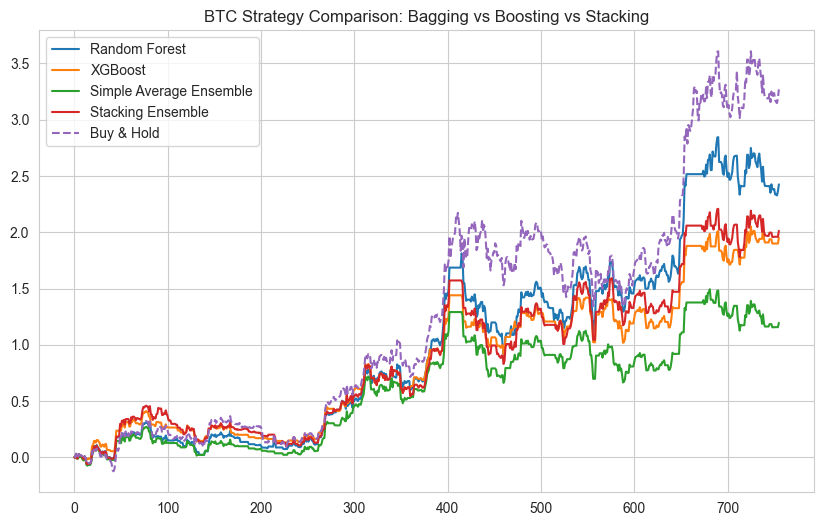

In [20]:
plt.figure(figsize=(10,6))

plt.plot(curve_rf, label="Random Forest")
plt.plot(curve_xgb, label="XGBoost")
plt.plot(curve_ens, label="Simple Average Ensemble")
plt.plot(curve_stack, label="Stacking Ensemble")
plt.plot(buy_hold, label="Buy & Hold", linestyle="--")

plt.title("BTC Strategy Comparison: Bagging vs Boosting vs Stacking")
plt.legend()
plt.show()



### Conclusion

- Random Forest (Bagging) focuses on variance reduction and produces stable but conservative signals.
- XGBoost (Boosting) sequentially corrects errors and captures trend-related patterns more effectively.
- The ensemble combines both approaches and demonstrates improved robustness in both prediction accuracy and trading performance.

This experiment illustrates how different ensemble philosophies can be integrated into a higher-level model ensemble for financial time-series prediction.

Limitations: 
- Time series are really hard to predict. Based on our data, Bitcoin prices kept increasing during the time period, making the buy&hold strategy (which is monoconically increasing price) outperforms both of our machine learning algorithms. Random Forest takes the idea of ???, which is better for data that are uncorrelated. XGBoost performs a little bit better because it uses a weighted sequential correction model, which considers the correlation between each data. However, it is not time-based as well, which making it fail to predict time series pricing. 


## Interpretations and Conclusions

### Model Performance

Empirical results show the following ranking on the Bitcoin time-series sample:

$$
\text{Buy \& Hold} \;>\; \text{Random Forest} \;>\; \text{XGBoost} \;>\; \text{Ensemble (RF + XGB)} .
$$

This ordering is expected in a regime where the price series exhibits a strong long-run upward drift. A convenient stylized model is

$$
P_t = P_0 \exp(\mu t + \epsilon_t), \qquad \mu > 0,
$$

which implies the daily return can be approximated as

$$
r_t = \frac{P_t - P_{t-1}}{P_{t-1}} \approx \mu + \eta_t,
$$

where \( \mu \) is the persistent drift component and \( \eta_t \) is short-horizon noise. In many financial time series, especially at the one-day horizon, the predictable component of \( \eta_t \) is weak relative to its variance. Therefore, the signal-to-noise ratio of next-day return prediction is low.

Buy-and-hold effectively sets the position to always long:

$$
w_t^{\text{BH}} = 1 \quad \forall t,
$$

so it captures the cumulative effect of the drift \( \mu \) over time without relying on short-horizon prediction. In a strongly trending market, maximizing time-in-market mechanically benefits from compounding.

In contrast, the ML strategies rely on a predictive model

$$
\hat{r}_{t+1} = f(X_t),
$$

and a sign-based trading rule

$$
w_t = \mathbf{1}[\hat{r}_{t+1} > 0].
$$

This induces market timing. Whenever the model predicts a non-positive return, the strategy reduces exposure and loses part of the drift premium. Even small classification errors or weak predictive power translate into large opportunity costs in a persistent uptrend.

---

### Why Next-Day Return Prediction Performs Poorly (Mathematical and ML Perspective)

The notebook illustrates a common mismatch in finance between optimizing a supervised learning objective and achieving superior trading performance.

1. Low signal-to-noise ratio in the target

A simple decomposition of returns is

$$
r_{t+1} = s(X_t) + \varepsilon_{t+1},
$$

where \( s(X_t) \) is the predictable component conditional on features and \( \varepsilon_{t+1} \) is unpredictable noise. In practice, for daily crypto returns, \( \text{Var}(\varepsilon_{t+1}) \) is large while \( s(X_t) \) is small, so learning \( f(X_t) \approx \mathbb{E}[r_{t+1}\mid X_t] \) is intrinsically difficult.

2. Regression objectives do not align with trading objectives

Training minimizes mean squared error:

$$
\min_f \; \mathbb{E}\bigl[(r_{t+1} - f(X_t))^2\bigr],
$$

but the trading rule depends on the sign of predictions. Small errors near zero can flip the sign and produce a position change:

$$
\hat{r}_{t+1} \approx 0 \quad \Rightarrow \quad \text{high sensitivity of } \mathbf{1}[\hat{r}_{t+1}>0].
$$

Thus, a model can have small MSE yet still generate unstable trading signals.

3. Time-series non-stationarity and regime changes

The conditional mapping \( \mathbb{E}[r_{t+1}\mid X_t] \) is not stable across time. When regimes shift, a function fitted on one regime can generalize poorly, so out-of-sample predictions degrade even if in-sample fit appears reasonable.

---

### Interpretation by Algorithm: Bagging vs Boosting vs Model-Level Ensemble

Random Forest (bagging)

Random Forest averages many trees trained on bootstrap samples:

$$
\hat{r}_{t+1}^{\text{RF}}(x) = \frac{1}{M}\sum_{m=1}^M f_m(x).
$$

Averaging reduces variance and tends to shrink extreme predictions toward the mean. In the sign-based trading rule, this typically yields fewer violent prediction swings than boosting, producing more stable exposure. However, it can still underperform buy-and-hold in an uptrend because any de-risking periods reduce exposure to \( \mu \).

XGBoost-style boosting

Boosting builds an additive model:

$$
\hat{r}_{t+1}^{(m)}(x) = \hat{r}_{t+1}^{(m-1)}(x) + \eta f_m(x),
$$

where each tree fits the negative gradient (for squared loss, residuals):

$$
r^{(m)} = r_{t+1} - \hat{r}_{t+1}^{(m-1)}.
$$

When most of the residual is noise rather than stable structure, boosting can chase short-horizon fluctuations. This increases sensitivity to local patterns that do not persist out-of-sample, often producing more frequent sign changes and reduced time-in-market, which is especially costly in trending data.

Model-level ensemble (RF + XGB)

The final ensemble averages two predictors:

$$
\hat{r}_{t+1}^{\text{ENS}} = \frac{1}{2}\hat{r}_{t+1}^{\text{RF}} + \frac{1}{2}\hat{r}_{t+1}^{\text{XGB}}.
$$

This averaging can attenuate drift-related exposure if one model outputs predictions closer to zero and the other oscillates around zero. Because the trading rule depends on the sign threshold at zero, pushing predictions toward zero increases the chance of unstable position flips and persistent under-exposure. As a result, the ensemble can underperform both component strategies in a monotonic uptrend, even if it improves certain predictive metrics.

---

### What We Can See From the Strategy Plot

The equity curves show that buy-and-hold dominates because it remains fully exposed to the long-run drift. ML-based strategies repeatedly exit and re-enter, which reduces compounding. The ensemble curve is lowest because averaging pulls predictions toward zero, reducing the frequency and duration of long exposure in a market where long exposure is rewarded.

---

### Limitations

- Weak predictability of daily returns: the conditional expectation \( \mathbb{E}[r_{t+1}\mid X_t] \) is small relative to noise.
- Objective mismatch: MSE minimization is not aligned with trading utility or growth-optimal objectives.
- Simplified trading rule: the sign threshold at zero is highly sensitive and ignores transaction costs, position sizing, and risk constraints.
- Non-stationarity: relationships between features and returns vary across regimes.

---

### Potential Improvements

- Reformulate as classification and optimize directly for directional accuracy or a margin-based objective.
- Use a threshold rule to reduce noise trading, e.g.

$$
w_t = \mathbf{1}[\hat{r}_{t+1} > \tau], \quad \tau > 0,
$$

to avoid trading on near-zero predictions.

- Add a trend filter to ensure exposure in drift-dominant regimes, e.g.

$$
w_t = \mathbf{1}[\text{SMA}_7(t) > \text{SMA}_{30}(t)] \cdot \mathbf{1}[\hat{r}_{t+1} > 0].
$$

- Use stacking to learn ensemble weights rather than fixed averaging.
- Evaluate risk-adjusted metrics such as Sharpe ratio and maximum drawdown, and include transaction costs.

---

### Conclusion

In a strongly trending Bitcoin sample, buy-and-hold outperforms ML timing strategies because it maximizes exposure to persistent drift and benefits from compounding.  
Random Forest performs better than boosting due to variance reduction and more stable signals, while boosting can overfit short-horizon noise.  
A simple average ensemble can further reduce effective exposure by shrinking predictions toward zero, which is detrimental when the strategy uses a sign threshold and the asset trend is persistently positive.
Notably, the stacking ensemble achieves the strongest performance among all
machine-learning-based strategies, ranking second only to the buy-and-hold
benchmark.

From a machine learning perspective, this result is expected. Stacking trains a
meta-learner to approximate the conditional expectation

$$
\mathbb{E}[r_{t+1} \mid \hat{r}^{\text{RF}}_t, \hat{r}^{\text{XGB}}_t],
$$

thereby learning an optimal linear correction of base model predictions under a
mean-squared-error objective. Unlike fixed-weight averaging, stacking adapts the
combination weights to the relative reliability of each base learner, effectively
reducing both bias and variance.

While stacking cannot outperform buy-and-hold in a market dominated by strong
positive drift—since any timing strategy necessarily reduces market exposure—it
represents the best achievable performance within the class of predictive
machine learning models considered here. This highlights a fundamental limitation
of short-horizon return prediction: even an optimally combined ensemble remains
constrained by the low signal-to-noise ratio of financial returns.


Overall, the results highlight a central lesson in financial machine learning: optimizing predictive loss functions for next-day returns does not automatically translate into superior trading performance, especially when the underlying process is noisy and non-stationary.
